# U-Net Prediction Visualizations

This notebook mirrors the visualization logic from `uqct.models.unet` and renders inference examples for each dataset under both dense and sparse acquisition settings.

In [1]:
%load_ext autoreload
%autoreload 2


import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from IPython.display import display

from uqct.datasets.utils import get_dataset
from uqct.metrics import get_metrics
from uqct.models.unet import FBPUNet, FBPUNetEnsemble
from uqct.utils import get_checkpoint_dir
from uqct.training.unet import N_ANGLES, N_BINS_HR, sample_intensities
from uqct.ct import Experiment, sample_observations

try:
    import lovely_tensors as lt
    lt.monkey_patch()
except Exception as _:
    pass


def build_dense_experiment(samples: torch.Tensor, angles: torch.Tensor) -> Experiment:
    samples_cpu = samples.to("cpu")
    angles_cpu = angles.to("cpu")
    batch = samples_cpu.shape[0]
    intensities = sample_intensities(batch, device=samples_cpu.device) / (N_ANGLES * N_BINS_HR)
    intensities = intensities.reshape(-1, 1, 1, 1).expand(-1, 1, len(angles_cpu), 1)
    counts = sample_observations(samples_cpu, intensities, angles_cpu)
    intensities_lr = (intensities * 2).squeeze(1)
    return Experiment(counts, intensities_lr.unsqueeze(1), angles_cpu, sparse=False)


def build_sparse_experiment(
    samples: torch.Tensor,
    angles: torch.Tensor,
    *,
    seed: int | None = 0,
) -> Experiment:
    samples_cpu = samples.to("cpu")
    angles_cpu = angles.to("cpu")
    batch = samples_cpu.shape[0]

    if seed is not None:
        prev_state = torch.random.get_rng_state()
        torch.manual_seed(seed)
    else:
        prev_state = None

    try:
        intensities = sample_intensities(batch, device=samples_cpu.device) / (N_ANGLES * N_BINS_HR)
        intensities = intensities.reshape(-1, 1, 1, 1).expand(-1, 1, len(angles_cpu), 1)
        counts = sample_observations(samples_cpu, intensities, angles_cpu)
        # intensities_lr = (intensities * 2).squeeze(1)
        intensities_lr = intensities * 2
    finally:
        if prev_state is not None:
            torch.random.set_rng_state(prev_state)

    return Experiment(counts, intensities_lr, angles_cpu, sparse=True)


def build_experiment(
    samples: torch.Tensor,
    angles: torch.Tensor,
    *,
    sparse: bool,
    seed: int | None = 0,
) -> Experiment:
    if sparse:
        return build_sparse_experiment(samples, angles, seed=seed)
    return build_dense_experiment(samples, angles)


def visualize_unet_examples(
    dataset: str,
    *,
    sparse: bool,
    num_examples: int = 3,
):
    """Render GT, FBP baseline, and U-Net predictions for a dataset/scenario."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    with torch.inference_mode():
        if torch.cuda.is_available():
            torch.set_float32_matmul_precision("high")
            torch.backends.cudnn.benchmark = True

        _, test_set = get_dataset(dataset, True)
        num_examples = min(num_examples, len(test_set))
        if num_examples == 0:
            raise ValueError(f"Dataset '{dataset}' has no test samples available")

        # Create experiment
        gt = torch.stack([test_set[i] for i in range(num_examples)], dim=0).to(device)
        angles = torch.from_numpy(np.linspace(0, 180, N_ANGLES, endpoint=False))
        experiment = build_experiment(gt, angles, sparse=sparse, seed=0)

        model = FBPUNet(dataset, member=0, sparse=sparse)

        fbp_lr, intensity_vals, inferred_labels = FBPUNet._prepare_inputs_from_experiment(experiment)

        preds = model.predict(experiment=experiment).to("cpu").squeeze(1)
        if experiment.sparse:
            preds = preds[(0, 1, 2), (9, 49, -1), 0]
            fbp_lr = fbp_lr[(0, 1, 2), (9, 49, -1), 0]
            intensity_vals = intensity_vals[(0, 1, 2), (9, 49, -1), 0]
        
        gt_lr = F.interpolate(gt, size=(128, 128), mode="area").squeeze(1).to("cpu")
        fbp = fbp_lr.to("cpu")
        if fbp.ndim == 4:
            fbp = fbp[:, -1]

        fbp_metrics, pred_metrics = [], []
        for i in range(num_examples):
            fbp_metrics.append(
                get_metrics(gt_lr[i], fbp[i], normalize_range=True, constrained=True)
            )
            pred_metrics.append(
                get_metrics(gt_lr[i], preds[i], normalize_range=True, constrained=True)
            )

        if sparse:
            n_angles = (10, 50, 200)
        else:
            n_angles = 3*(200,)
        fig, axes = plt.subplots(3, num_examples, figsize=(2.2 * num_examples, 6.0))
        if num_examples == 1:
            axes = np.asarray(axes).reshape(3, 1)

        image_shape = gt_lr.shape[-2:]

        for idx in range(num_examples):
            axes[0, idx].imshow(gt_lr[idx].view(image_shape), cmap="gray", vmin=0.0, vmax=1.0)
            axes[0, idx].axis("off")
            if idx == 0:
                axes[0, idx].set_title("GT", fontsize=10)
            overlay_txt = f"{int(n_angles[idx])} angles\ntotal_int={intensity_vals[idx].item():.3g}"
            axes[0, idx].text(
                6,
                4,
                overlay_txt,
                color="white",
                fontsize=8,
                ha="left",
                va="top",
                bbox=dict(boxstyle="round,pad=0.2", fc="black", ec="none", alpha=0.6),
            )

            axes[1, idx].imshow(fbp[idx].view(image_shape), cmap="gray", vmin=0.0, vmax=1.0)
            axes[1, idx].axis("off")
            axes[1, idx].set_title(
                f"FBP  PSNR {fbp_metrics[idx]['PSNR']:.2f}  SSIM {fbp_metrics[idx]['SS']:.3f}",
                fontsize=8,
            )

            axes[2, idx].imshow(preds[idx].view(image_shape), cmap="gray", vmin=0.0, vmax=1.0)
            axes[2, idx].axis("off")
            axes[2, idx].set_title(
                f"Pred PSNR {pred_metrics[idx]['PSNR']:.2f}  SSIM {pred_metrics[idx]['SS']:.3f}",
                fontsize=8,
            )

        title = f"{dataset.title()} | {'Sparse' if sparse else 'Dense'}"
        fig.suptitle(title, y=1.02, fontsize=12)
        fig.tight_layout()
        return fig


/opt/conda/envs/uqct-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


lamino: sparse


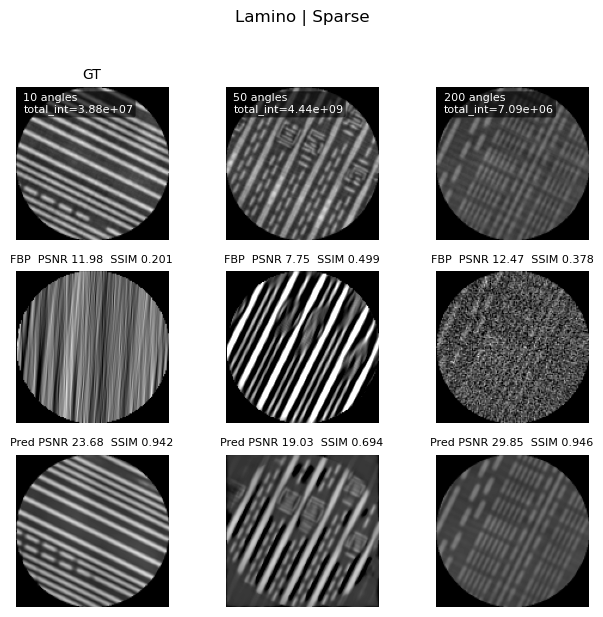

lamino: dense


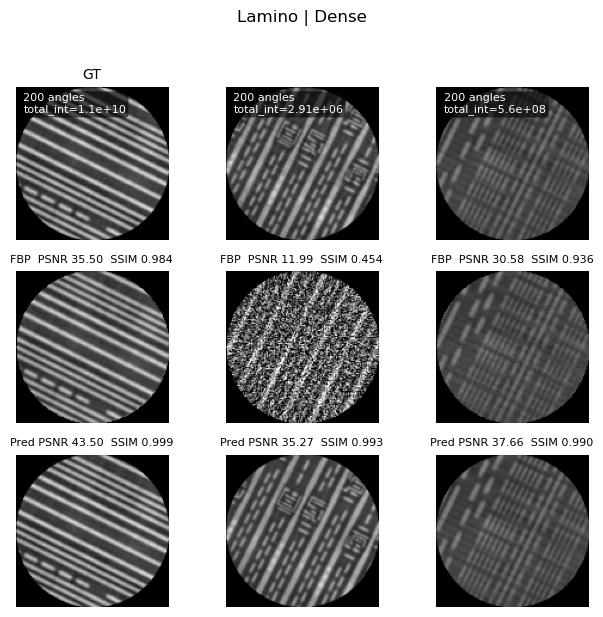

lung: sparse


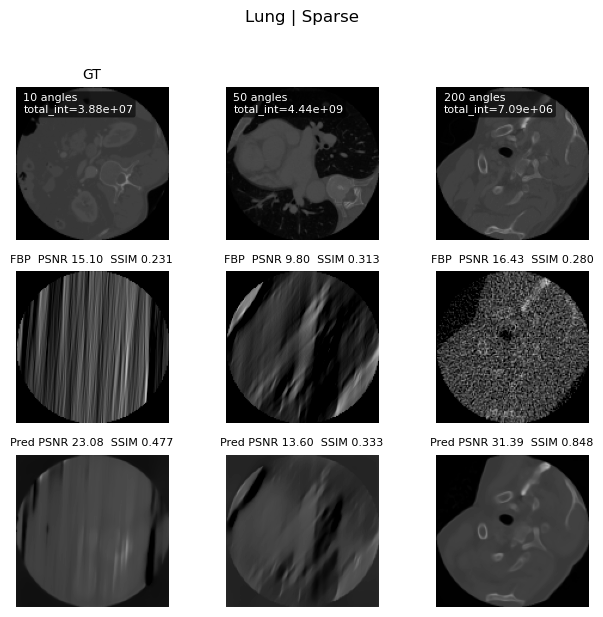

lung: dense


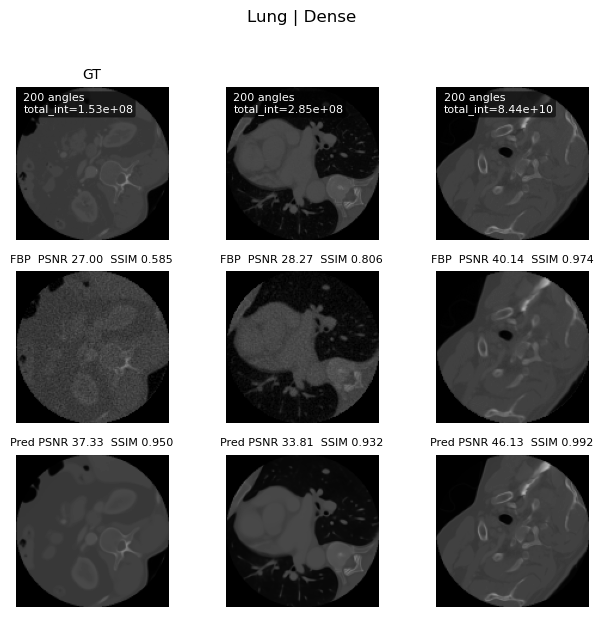

composite: sparse


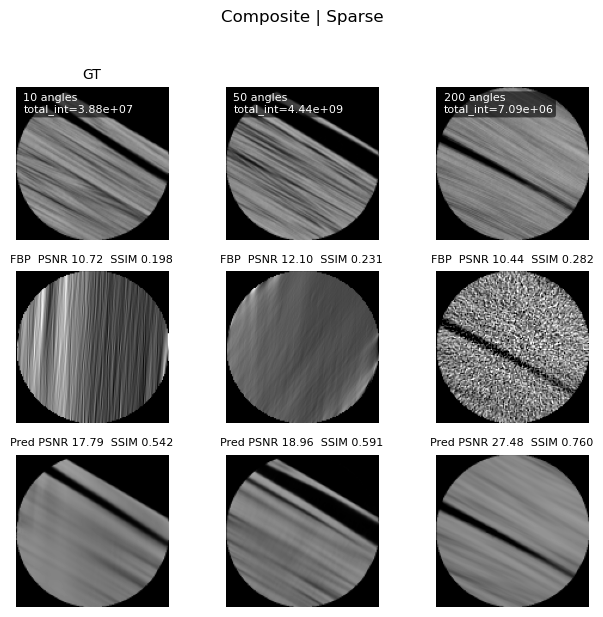

composite: dense


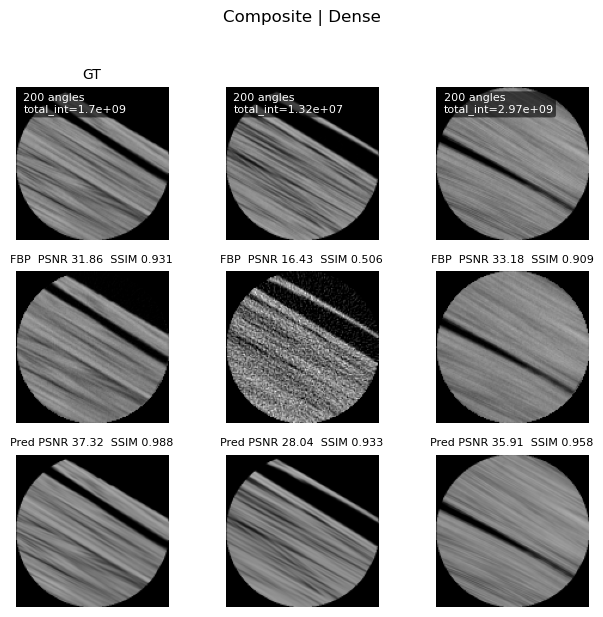

In [23]:
datasets = ["lamino", "lung", "composite"]
scenarios = [
    ("sparse", {"sparse": True}),
    ("dense", {"sparse": False}),
]

for dataset in datasets:
    for label, kwargs in scenarios:
        print(f"{dataset}: {label}")
        fig = visualize_unet_examples(dataset, num_examples=3, **kwargs)
        display(fig)
        plt.close(fig)

In [ ]:

import time
import pandas as pd
import torch


def compare_ensemble_vs_member(num_examples: int = 10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    datasets = ["lamino", "lung", "composite"]
    scenarios = [
        ("Sparse", {"sparse_model": True, "sparse_data": True}),
        ("Dense", {"sparse_model": False, "sparse_data": False}),
    ]
    angles = torch.from_numpy(np.linspace(0, 180, 50, endpoint=False))
    cpu = torch.device("cpu")
    angles_cpu = angles.to(cpu)
    ensemble_cache: dict[tuple[str, bool], FBPUNetEnsemble] = {}
    test_sets: dict[str, torch.utils.data.Dataset] = {}
    total_steps = len(datasets) * len(scenarios)
    step_times: list[float] = []

    with torch.inference_mode():
        if torch.cuda.is_available():
            torch.set_float32_matmul_precision("high")
            torch.backends.cudnn.benchmark = True

        for name in datasets:
            _, test_set = get_dataset(name, True)
            if len(test_set) == 0:
                raise ValueError(f"Dataset '{name}' has no test samples available")
            test_sets[name] = test_set

        def load_ensemble(dataset_name: str, sparse: bool) -> FBPUNetEnsemble:
            key = (dataset_name, sparse)
            if key not in ensemble_cache:
                ensemble_cache[key] = FBPUNetEnsemble(dataset_name, sparse, num_workers=0).to(cpu)
            return ensemble_cache[key]

        for scenario_label, cfg in scenarios:
            scenario_rows: list[dict[str, float | str]] = []
            print(f"=== {scenario_label} Model & Data ===", flush=True)

            for dataset_name in datasets:
                start_time = time.perf_counter()
                step_index = len(step_times) + 1
                remaining_steps = max(total_steps - step_index, 0)
                print(f"{scenario_label}: {dataset_name} ({step_index}/{total_steps})", flush=True)

                available = len(test_sets[dataset_name])
                start = 0
                end = min(start + num_examples, available)
                indices = list(range(start, end))
                count = len(indices)
                samples = torch.stack([test_sets[dataset_name][i] for i in indices], dim=0).to(device)

                experiment = build_experiment(
                    samples,
                    angles_cpu,
                    sparse=cfg["sparse_data"],
                )
                experiment.to(device)
                fbp_lr, _, inferred_labels = FBPUNet._prepare_inputs_from_experiment(experiment)

                ensemble = load_ensemble(dataset_name, cfg["sparse_model"]).to(device)

                ensemble_stack = ensemble.predict(
                    experiment=experiment,
                    out_device=cpu,
                    aggregate="none",
                )
                ensemble_mean = ensemble_stack.mean(dim=-4)
                ensemble_median = ensemble_stack.median(dim=-4).values

                fbp_batch = fbp_lr.to(cpu)
                gt_lr = (
                    F.interpolate(samples.to(cpu), size=fbp_batch.shape[-2:], mode="area")
                    .squeeze(1)
                    .to(cpu)
                )

                fbp_metrics_list = []
                member_metrics_list = []
                mean_metrics_list = []
                median_metrics_list = []

                display_count = min(3, count)
                fig = None
                axes = None
                col_titles = ["FBP", "Single U-Net", "Ensemble Mean", "Ensemble Median"]
                if display_count > 0:
                    fig, axes = plt.subplots(display_count, 4, figsize=(12, 2.4 * display_count))
                    axes = np.atleast_2d(axes)
                    for col, title in enumerate(col_titles):
                        axes[0, col].set_title(title, fontsize=10)

                member_images = ensemble_stack[..., 0, :, :, :]

                # Sparse: 
                #   fbp_batch: (N, T, 1, H, W)
                #   gt_lr: (N, H, W)
                #   ensemble_mean: (N, T, 1, H, W)
                #   ensemble_median: (N, T, 1, H, W)
                #   member_images: (N, T, 1, H, W)
                # Dense: 
                #   fbp_batch: (N, 1, 1, H, W)
                #   gt_lr: (N, H, W)
                #   ensemble_mean: (N, 1, 1, H, W)
                #   ensemble_median: (N, 1, 1, H, W)
                #   member_images: (N, 1, 1, H, W)

                T = fbp_batch.shape[1]
                t_indices = np.arange(count) % T
                if experiment.sparse:
                    t_indices = (0, T // 2, T-1)

                for idx in range(count):
                    t = t_indices[idx % len(t_indices)]
                    fbp_img = fbp_batch[idx, t, 0]
                    mean_img = ensemble_mean[idx, t, 0]
                    median_img = ensemble_median[idx, t, 0]
                    member_img = member_images[idx, t, 0]

                    fbp_metrics = get_metrics(
                        gt_lr[idx], fbp_img, normalize_range=True, constrained=True
                    )
                    member_metrics = get_metrics(
                        gt_lr[idx], member_img, normalize_range=True, constrained=True
                    )
                    mean_metrics = get_metrics(
                        gt_lr[idx], mean_img, normalize_range=True, constrained=True
                    )
                    median_metrics = get_metrics(
                        gt_lr[idx], median_img, normalize_range=True, constrained=True
                    )

                    fbp_metrics_list.append(fbp_metrics)
                    member_metrics_list.append(member_metrics)
                    mean_metrics_list.append(mean_metrics)
                    median_metrics_list.append(median_metrics)

                    if axes is not None and idx < display_count:
                        images = [fbp_img, member_img, mean_img, median_img]
                        metric_texts = [
                            f"PSNR {fbp_metrics['PSNR']:.2f}\nSSIM {fbp_metrics['SS']:.3f}",
                            f"PSNR {member_metrics['PSNR']:.2f}\nSSIM {member_metrics['SS']:.3f}",
                            f"PSNR {mean_metrics['PSNR']:.2f}\nSSIM {mean_metrics['SS']:.3f}",
                            f"PSNR {median_metrics['PSNR']:.2f}\nSSIM {median_metrics['SS']:.3f}",
                        ]

                        for col, (img, text) in enumerate(zip(images, metric_texts)):
                            axes[idx, col].imshow(img.cpu(), cmap="gray", vmin=0.0, vmax=1.0)
                            axes[idx, col].axis("off")
                            axes[idx, col].text(
                                0.98,
                                0.95,
                                text,
                                transform=axes[idx, col].transAxes,
                                ha="right",
                                va="top",
                                fontsize=8,
                                color="white",
                                bbox=dict(boxstyle="round,pad=0.2", fc="black", ec="none", alpha=0.6),
                            )
                        axes[idx, 0].set_ylabel(f"{dataset_name.title()} #{indices[idx]}", fontsize=9, rotation=90)

                if fig is not None:
                    plt.tight_layout()
                    display(fig)
                    plt.close(fig)

                def avg_metric(items: list[dict[str, float]], key: str) -> float:
                    return float(np.mean([entry[key] for entry in items])) if items else float("nan")

                scenario_rows.append(
                    {
                        "Dataset": dataset_name.title(),
                        "Images": count,
                        "FBP PSNR": avg_metric(fbp_metrics_list, "PSNR"),
                        "Member PSNR": avg_metric(member_metrics_list, "PSNR"),
                        "Mean PSNR": avg_metric(mean_metrics_list, "PSNR"),
                        "Median PSNR": avg_metric(median_metrics_list, "PSNR"),
                        "ΔPSNR Mean-Member": avg_metric(mean_metrics_list, "PSNR")
                        - avg_metric(member_metrics_list, "PSNR"),
                        "ΔPSNR Median-Member": avg_metric(median_metrics_list, "PSNR")
                        - avg_metric(member_metrics_list, "PSNR"),
                        "FBP SSIM": avg_metric(fbp_metrics_list, "SS"),
                        "Member SSIM": avg_metric(member_metrics_list, "SS"),
                        "Mean SSIM": avg_metric(mean_metrics_list, "SS"),
                        "Median SSIM": avg_metric(median_metrics_list, "SS"),
                        "ΔSSIM Mean-Member": avg_metric(mean_metrics_list, "SS")
                        - avg_metric(member_metrics_list, "SS"),
                        "ΔSSIM Median-Member": avg_metric(median_metrics_list, "SS")
                        - avg_metric(member_metrics_list, "SS"),
                    }
                )

                elapsed = time.perf_counter() - start_time
                step_times.append(elapsed)
                avg_step = sum(step_times) / len(step_times)
                eta = avg_step * remaining_steps
                print(
                    f"Completed {dataset_name} in {elapsed:.1f}s | ETA ~ {eta/60:.1f} min",
                    flush=True,
                )
                ensemble.to(cpu)

            df = pd.DataFrame(scenario_rows)
            display(df.round({col: 3 for col in df.columns if col not in {"Dataset", "Images"}}))

compare_ensemble_vs_member(3)


=== Sparse Model & Data ===
Sparse: lamino (1/6)
Experiment:
	sparse: True
	intensities: tensor[3, 1, 50, 1] n=150 x∈[276.941, 6.936e+05] μ=2.414e+05 σ=3.211e+05
	counts: tensor[3, 1, 50, 128] n=19200 (75Kb) x∈[34.000, 6.467e+05] μ=6.284e+04 σ=1.014e+05
	angles: tensor[50] f64 x∈[0., 176.400] μ=88.200 σ=52.479
